In [2]:
from google.colab import drive
import os

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define the path to your dataset folder
dataset_path = '/content/drive/My Drive/Dinuja final year project'

# Check if the folder exists
if os.path.exists(dataset_path):
    print(f"Folder found: {dataset_path}")
else:
    print("Folder not found. Please check the path.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder found: /content/drive/My Drive/Dinuja final year project


In [3]:
import os

# Define the root folder path
root_folder = '/content/drive/My Drive/Dinuja final year project'

# Function to print folder structure
def print_folder_structure(folder_path, indent=0):
    try:
        for item in os.listdir(folder_path):
            item_path = os.path.join(folder_path, item)
            if os.path.isdir(item_path):
                print("  " * indent + f"[Folder] {item}")
                print_folder_structure(item_path, indent + 1)
            else:
                print("  " * indent + f"- {item}")
    except Exception as e:
        print(f"Error accessing {folder_path}: {e}")

# Print the folder structure
print(f"Folder structure for: {root_folder}")
print_folder_structure(root_folder)


Folder structure for: /content/drive/My Drive/Dinuja final year project
- archive (3).zip
[Folder] datas
  [Folder] test
    [Folder] drugged
      - IMG_20230518_213809.jpg
      - IMG_20230518_213820 - Copy (2).jpg
      - IMG_20230518_213832 - Copy.jpg
      - IMG_20230518_213832 - Copy (2).jpg
      - IMG_20230518_213809 - Copy (2).jpg
      - IMG_20230518_213809 - Copy.jpg
      - IMG_20230518_213844 - Copy (2).jpg
      - IMG_20230518_213832.jpg
      - IMG_20230518_213745 - Copy (2).jpg
      - IMG_20230518_213734 - Copy.jpg
      - IMG_20230518_213734.jpg
      - IMG_20230518_213745 - Copy.jpg
      - IMG_20230518_213745.jpg
      - IMG_20230518_213820.jpg
      - IMG_20230518_213820 - Copy.jpg
      - IMG_20230518_213717 - Copy (2).jpg
      - IMG_20230518_213717.jpg
      - IMG_20230518_213734 - Copy (2).jpg
      - IMG_20230518_213717 - Copy.jpg
      - IMG_20230518_213707 - Copy (2).jpg
      - IMG_20230518_213707 - Copy.jpg
      - IMG_20230518_213648.jpg
      - IMG_20230

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
train_dir = '/content/drive/My Drive/Dinuja final year project/datas/train'
test_dir = '/content/drive/My Drive/Dinuja final year project/datas/test'

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 224, 224

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,          # Normalize pixel values
    rotation_range=20,          # Augmentation: Rotate images
    width_shift_range=0.2,      # Augmentation: Horizontal shift
    height_shift_range=0.2,     # Augmentation: Vertical shift
    shear_range=0.2,            # Augmentation: Shear transformation
    zoom_range=0.2,             # Augmentation: Zoom in/out
    horizontal_flip=True,       # Augmentation: Flip horizontally
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize test images

# Create data generators
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='binary'  # Binary classification: drunked vs. normal
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='binary'
)

# Verify class labels
print(f"Class indices: {train_data.class_indices}")


Found 352 images belonging to 2 classes.
Found 366 images belonging to 2 classes.
Class indices: {'drugged': 0, 'normal': 1}


In [5]:
from tensorflow.keras.models import Sequential  # Import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Build the CNN model with Input layer
model = Sequential([
    Input(shape=(224, 224, 3)),  # Define input shape explicitly
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,  # You can start with 10 and increase based on results
      # Number of parallel processes for data loading
      # Enable multiprocessing for faster data loading
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 144s 13s/step - accuracy: 0.5947 - loss: 0.9241 - val_accuracy: 0.8470 - val_loss: 0.7481
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.7916 - loss: 0.4586 - val_accuracy: 0.8470 - val_loss: 0.8976
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.8947 - loss: 0.3602 - val_accuracy: 0.8060 - val_loss: 0.5642
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step - accuracy: 0.9294 - loss: 0.2611 - val_accuracy: 0.8470 - val_loss: 0.9761
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.9428 - loss: 0.2976 - val_accuracy: 0.8470 - val_loss: 0.4981
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.9449 - loss: 0.1760 - val_accuracy: 0.8470 - val_loss: 0.4699
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.9755 - loss: 0.1064 - val_accuracy: 0.8470 - val_loss: 0.7193
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.9663 - loss: 0.1498 - val_accuracy: 0.8470 - val_los

If need rin these to get the statistics of training process.

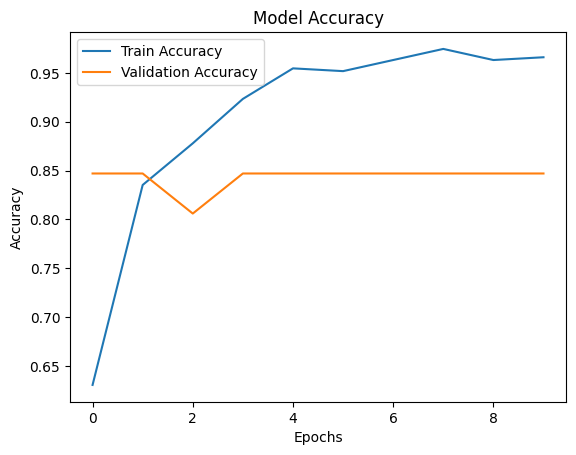

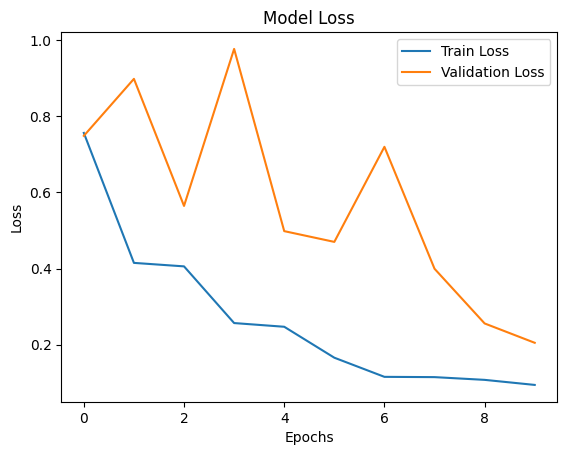

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [8]:
model.save('/content/drive/My Drive/Dinuja final year project/iris_drunkenness_model.h5')
model.save('/content/drive/My Drive/Dinuja final year project/iris_drunkenness_model.keras')


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


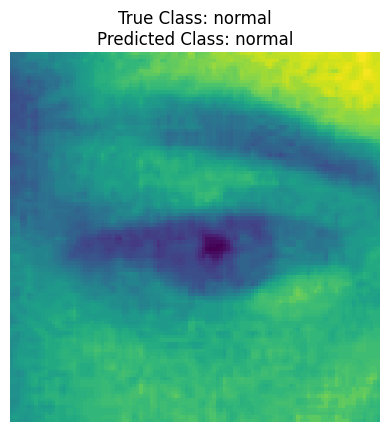

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the trained model
model_path = '/content/drive/My Drive/Dinuja final year project/iris_drunkenness_model.keras'  # Adjust if needed
model = load_model(model_path)

# Path to the test dataset
test_image_dir = '/content/drive/My Drive/Dinuja final year project/datas/test'

# Class names (ensure they match the ImageDataGenerator class mapping)
class_names = {'drugged': 0, 'normal': 1}
inverse_class_names = {v: k for k, v in class_names.items()}

# Select a random class and image
random_class = np.random.choice(list(class_names.keys()))
class_path = os.path.join(test_image_dir, random_class)
image_files = os.listdir(class_path)
random_image = np.random.choice(image_files)

# Load and preprocess the image
image_path = os.path.join(class_path, random_image)
img = load_img(image_path, target_size=(224, 224))  # Resize to model's input size
img_array = img_to_array(img) / 255.0  # Normalize pixel values
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Make a prediction
prediction = model.predict(img_array)
predicted_class_index = int(prediction[0][0] > 0.5)  # Threshold of 0.5 for binary classification
predicted_class = inverse_class_names[predicted_class_index]

# Display the image and prediction
plt.imshow(plt.imread(image_path))
plt.title(f"True Class: {random_class}\nPredicted Class: {predicted_class}")
plt.axis('off')
plt.show()


In [10]:
# Path to your own image
custom_image_path = 'custom_image.jpg'

# Load and preprocess the image
img = load_img(custom_image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0  # Normalize pixel values
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Make a prediction
prediction = model.predict(img_array)
predicted_class_index = int(prediction[0][0] > 0.5)  # Threshold for binary classification
predicted_class = inverse_class_names[predicted_class_index]

# Display the image and prediction
plt.imshow(plt.imread(custom_image_path))
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'custom_image.jpg'

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load pre-trained eye detection model from OpenCV
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

def detect_eye(image_path):
    """Detects eyes in the image and returns True if an eye is detected, else False."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    eyes = eye_cascade.detectMultiScale(gray, 1.1, 4)  # Detect eyes

    return len(eyes) > 0  # Returns True if at least one eye is detected

# Path to your image
custom_image_path = 'test.jpg'

# Validate if the image contains an eye
if detect_eye(custom_image_path):
    # Load and preprocess the image
    img = load_img(custom_image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make a prediction
    prediction = model.predict(img_array)
    predicted_class_index = int(prediction[0][0] > 0.5)  # Threshold for binary classification
    predicted_class = inverse_class_names[predicted_class_index]

    # Display the image and prediction
    plt.imshow(plt.imread(custom_image_path))
    plt.title(f"Predicted Class: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("No eye detected in the image. Please upload a valid eye image.")

No eye detected in the image. Please upload a valid eye image.
